In [1]:
# ============================================================
# PROJECT 3: RFM Customer Segmentation
# K-Means Clustering on 541,909 E-Commerce Transactions
# ============================================================

!pip install kaggle -q

import os, json

kaggle_credentials = {
    "username": "cynthiawanjiku",
    "key": "KGAT_8230434584795821c21884683601bd65"
}

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d mashlyn/online-retail-ii-uci --unzip -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('online_retail_II.csv', encoding='latin-1')

print(f"✅ Dataset loaded — {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\n📋 Columns: {df.columns.tolist()}")
print(f"\n🔍 Sample:")
print(df.head(3))

Dataset URL: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci
License(s): CC0-1.0
✅ Dataset loaded — 1,067,371 rows, 8 columns

📋 Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

🔍 Sample:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  


In [2]:
# ============================================================
# CELL 3: Data Cleaning & RFM Calculation
# ============================================================

print("🧹 Cleaning data...")

# Parse dates
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove cancellations (invoices starting with C)
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove rows with no Customer ID
df = df.dropna(subset=['Customer ID'])

# Remove negative or zero quantities and prices
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Calculate revenue per line
df['Revenue'] = df['Quantity'] * df['Price']

# Convert Customer ID to integer
df['Customer ID'] = df['Customer ID'].astype(int)

print(f"✅ After cleaning — {df.shape[0]:,} rows")
print(f"👥 Unique customers: {df['Customer ID'].nunique():,}")
print(f"📅 Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"💰 Total revenue: ${df['Revenue'].sum():,.2f}")

# ============================================================
# RFM CALCULATION
# ============================================================

# Reference date = 1 day after last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"\n📅 Reference date: {reference_date.date()}")

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

print(f"\n📊 RFM Summary:")
print(rfm.describe().round(2))

🧹 Cleaning data...
✅ After cleaning — 805,549 rows
👥 Unique customers: 5,878
📅 Date range: 2009-12-01 to 2011-12-09
💰 Total revenue: $17,743,429.18

📅 Reference date: 2011-12-10

📊 RFM Summary:
       Customer ID  Recency  Frequency   Monetary
count      5878.00  5878.00    5878.00    5878.00
mean      15315.31   201.33       6.29    3018.62
std        1715.57   209.34      13.01   14737.73
min       12346.00     1.00       1.00       2.95
25%       13833.25    26.00       1.00     348.76
50%       15314.50    96.00       3.00     898.92
75%       16797.75   380.00       7.00    2307.09
max       18287.00   739.00     398.00  608821.65


In [3]:
# ============================================================
# CELL 4: K-Means Clustering & Segment Labeling
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Log transform to handle skewness
rfm_log = rfm.copy()
rfm_log['Recency']   = np.log1p(rfm['Recency'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm['Monetary'])

# Scale
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency','Frequency','Monetary']])

# Find optimal k using silhouette score
print("🔍 Finding optimal number of clusters...")
sil_scores = {}
inertias = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    sil_scores[k] = silhouette_score(rfm_scaled, labels)
    inertias[k] = km.inertia_
    print(f"  k={k}: silhouette={sil_scores[k]:.4f}, inertia={inertias[k]:.1f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n✅ Best k = {best_k} (silhouette = {sil_scores[best_k]:.4f})")

# Train final model
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Analyze clusters
cluster_summary = rfm.groupby('Cluster').agg(
    Customers  = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency', 'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary', 'mean'),
    Total_Revenue = ('Monetary', 'sum')
).round(2)

print("\n📊 Cluster Summary:")
print(cluster_summary)

🔍 Finding optimal number of clusters...
  k=2: silhouette=0.4381, inertia=8588.8
  k=3: silhouette=0.3478, inertia=6352.0
  k=4: silhouette=0.3653, inertia=4918.6
  k=5: silhouette=0.3421, inertia=4097.8
  k=6: silhouette=0.3336, inertia=3553.0
  k=7: silhouette=0.3052, inertia=3184.8
  k=8: silhouette=0.2970, inertia=2891.6

✅ Best k = 2 (silhouette = 0.4381)

📊 Cluster Summary:
         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue
Cluster                                                                    
0             2352        51.15          12.59       6619.45    15568957.61
1             3526       301.51           2.09        616.70     2174471.56


In [4]:
# ============================================================
# CELL 5: Force k=4 for Business-Meaningful Segments
# ============================================================

# Override to 4 clusters — more actionable for business
kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans4.fit_predict(rfm_scaled)

# Analyze each cluster
cluster_summary = rfm.groupby('Cluster').agg(
    Customers     = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency', 'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary', 'mean'),
    Total_Revenue = ('Monetary', 'sum')
).round(2)

print("📊 Cluster Analysis (k=4):")
print(cluster_summary)
print(f"\nTotal revenue check: ${cluster_summary['Total_Revenue'].sum():,.2f}")

# Label segments based on RFM profile
# Low Recency = bought recently (good), High Recency = bought long ago (bad)
# High Frequency = buys often (good), High Monetary = high spender (good)
def label_segment(row):
    r = row['Avg_Recency']
    f = row['Avg_Frequency']
    m = row['Avg_Monetary']

    if r < 100 and f > 8 and m > 3000:
        return 'Champions'
    elif r < 150 and f > 4:
        return 'Loyal Customers'
    elif r > 200 and f < 3:
        return 'Lost / Inactive'
    else:
        return 'At-Risk'

cluster_summary['Segment'] = cluster_summary.apply(label_segment, axis=1)
print("\n🏷️ Segment Labels:")
print(cluster_summary[['Customers','Avg_Recency','Avg_Frequency',
                        'Avg_Monetary','Total_Revenue','Segment']])

# Map labels back to main dataframe
segment_map = cluster_summary['Segment'].to_dict()
rfm['Segment'] = rfm['Cluster'].map(segment_map)

print("\n✅ Segments assigned:")
print(rfm['Segment'].value_counts())
print(f"\n💰 Revenue by segment:")
print(rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))

📊 Cluster Analysis (k=4):
         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue
Cluster                                                                    
0             1188        27.43          19.34      11014.37    13085069.69
1             1974       395.86           1.38        325.75      643026.91
2             1465       227.87           5.10       2002.10     2933080.13
3             1251        28.44           3.04        865.11     1082252.45

Total revenue check: $17,743,429.18

🏷️ Segment Labels:
         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  \
Cluster                                                                       
0             1188        27.43          19.34      11014.37    13085069.69   
1             1974       395.86           1.38        325.75      643026.91   
2             1465       227.87           5.10       2002.10     2933080.13   
3             1251        28.44           3.04        865.11     1

In [5]:
# ============================================================
# CELL 6: Fix Segment Labels — Split the Two At-Risk Clusters
# ============================================================

# Cluster 3: Recent buyers (28 days), low frequency — these are New/Promising
# Cluster 2: 228 days ago, medium frequency — these are genuinely At-Risk
def label_segment_v2(cluster):
    mapping = {
        0: 'Champions',        # Recent, high freq, high spend
        1: 'Lost / Inactive',  # 396 days ago, barely bought
        2: 'At-Risk',          # 228 days ago, medium — slipping away
        3: 'New / Promising'   # Recent but low freq — just starting out
    }
    return mapping[cluster]

rfm['Segment'] = rfm['Cluster'].map(label_segment_v2)

# Final summary
segment_stats = rfm.groupby('Segment').agg(
    Customers     = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency', 'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary', 'mean'),
    Total_Revenue = ('Monetary', 'sum')
).round(2)

segment_stats['Revenue_Share_Pct'] = (
    segment_stats['Total_Revenue'] / segment_stats['Total_Revenue'].sum() * 100
).round(1)

print("🏷️ Final Segment Summary:")
print(segment_stats.to_string())

print("\n📊 Customer count:")
print(rfm['Segment'].value_counts())

print("\n💰 Revenue by segment:")
for seg, row in segment_stats.sort_values('Total_Revenue', ascending=False).iterrows():
    print(f"  {seg:20s}: ${row['Total_Revenue']:>12,.0f}  ({row['Revenue_Share_Pct']}%)")

🏷️ Final Segment Summary:
                 Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Revenue_Share_Pct
Segment                                                                                               
At-Risk               1465       227.87           5.10       2002.10     2933080.13               16.5
Champions             1188        27.43          19.34      11014.37    13085069.69               73.7
Lost / Inactive       1974       395.86           1.38        325.75      643026.91                3.6
New / Promising       1251        28.44           3.04        865.11     1082252.45                6.1

📊 Customer count:
Segment
Lost / Inactive    1974
At-Risk            1465
New / Promising    1251
Champions          1188
Name: count, dtype: int64

💰 Revenue by segment:
  Champions           : $  13,085,070  (73.7%)
  At-Risk             : $   2,933,080  (16.5%)
  New / Promising     : $   1,082,252  (6.1%)
  Lost / Inactive     : $     643,027  (3.6%

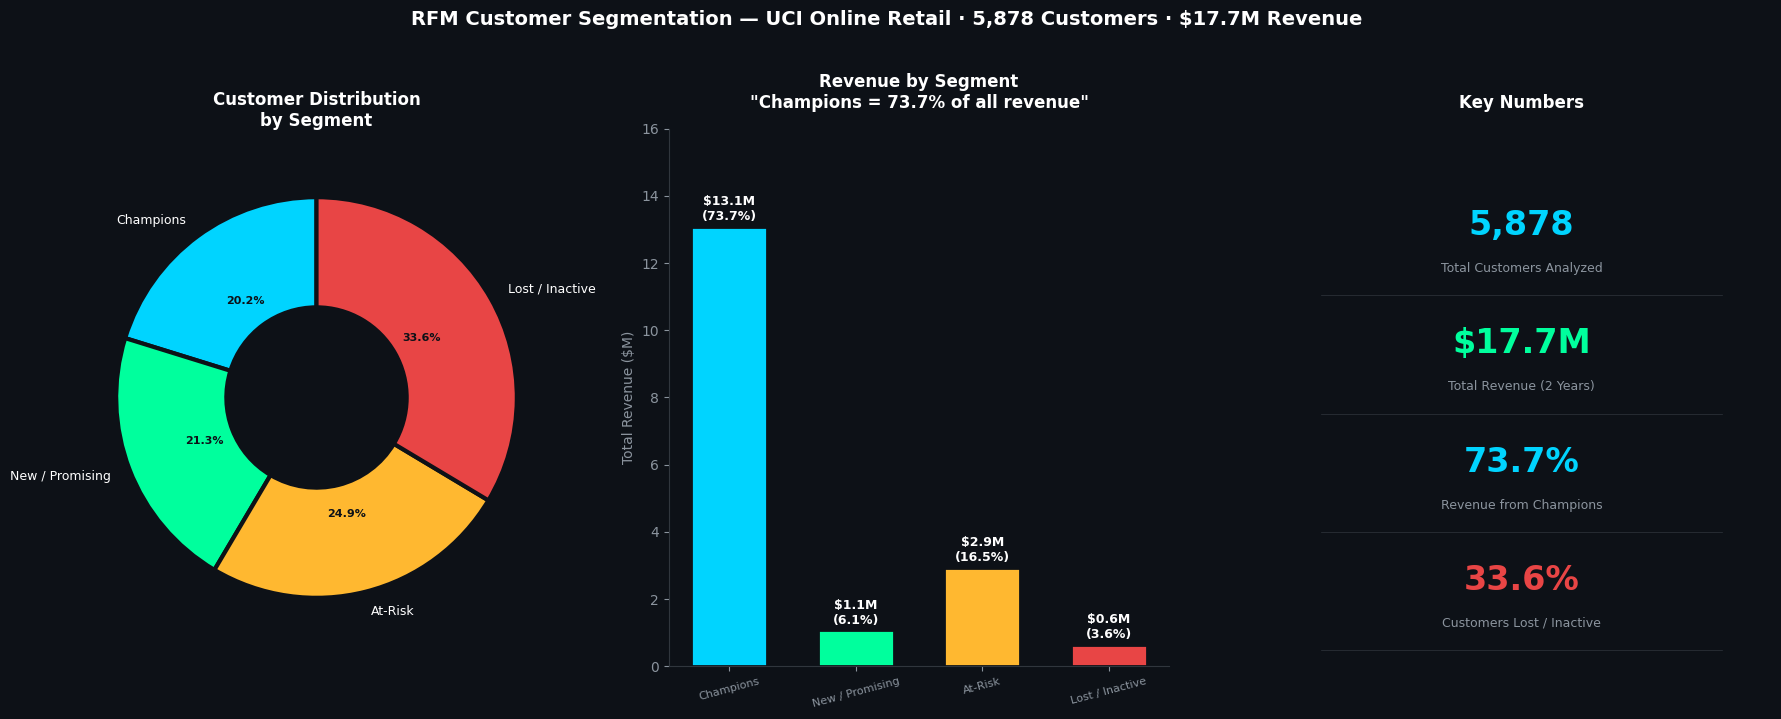

✅ Chart 1 saved


In [6]:
# ============================================================
# CELL 7: Chart 1 — Segment Overview Dashboard
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor('#0D1117')

seg_colors = {
    'Champions':       '#00D4FF',
    'New / Promising': '#00FF9D',
    'At-Risk':         '#FFB830',
    'Lost / Inactive': '#E84545'
}

seg_order = ['Champions', 'New / Promising', 'At-Risk', 'Lost / Inactive']
counts = [rfm['Segment'].value_counts()[s] for s in seg_order]
revenues = [segment_stats.loc[s, 'Total_Revenue'] for s in seg_order]
colors = [seg_colors[s] for s in seg_order]

# --- Donut: Customer Distribution ---
ax1 = axes[0]
ax1.set_facecolor('#0D1117')
wedges, texts, autotexts = ax1.pie(
    counts, labels=seg_order, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='#0D1117', linewidth=3),
    textprops=dict(color='white', fontsize=9)
)
for at in autotexts:
    at.set_fontsize(8)
    at.set_color('#0D1117')
    at.set_fontweight('bold')
ax1.set_title('Customer Distribution\nby Segment', fontsize=12,
              fontweight='bold', color='white', pad=15)

# --- Bar: Revenue by Segment ---
ax2 = axes[1]
ax2.set_facecolor('#0D1117')
bars = ax2.bar(seg_order, [r/1e6 for r in revenues],
               color=colors, width=0.6, edgecolor='#0D1117', linewidth=2)
for bar, rev, seg in zip(bars, revenues, seg_order):
    pct = rev / sum(revenues) * 100
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'${rev/1e6:.1f}M\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=9,
             color='white', fontweight='bold')
ax2.set_ylabel('Total Revenue ($M)', color='#8B949E', fontsize=10)
ax2.set_title('Revenue by Segment\n"Champions = 73.7% of all revenue"',
              fontsize=12, fontweight='bold', color='white', pad=15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_color('#30363D')
ax2.spines['left'].set_color('#30363D')
ax2.tick_params(colors='#8B949E')
ax2.set_xticklabels(seg_order, fontsize=8, rotation=15)
ax2.set_ylim(0, 16)

# --- KPI Cards ---
ax3 = axes[2]
ax3.set_facecolor('#161B22')
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis('off')
ax3.set_title('Key Numbers', fontsize=12, fontweight='bold',
              color='white', pad=15)
kpis = [
    ('5,878', 'Total Customers Analyzed', '#00D4FF'),
    ('$17.7M', 'Total Revenue (2 Years)', '#00FF9D'),
    ('73.7%', 'Revenue from Champions', '#00D4FF'),
    ('33.6%', 'Customers Lost / Inactive', '#E84545'),
]
for i, (num, label, color) in enumerate(kpis):
    y = 0.82 - i * 0.22
    ax3.text(0.5, y, num, ha='center', va='center',
             fontsize=24, fontweight='bold', color=color)
    ax3.text(0.5, y - 0.08, label, ha='center', va='center',
             fontsize=9, color='#8B949E')
    ax3.axhline(y=y-0.13, xmin=0.1, xmax=0.9,
                color='#30363D', linewidth=0.5)

fig.suptitle('RFM Customer Segmentation — UCI Online Retail · 5,878 Customers · $17.7M Revenue',
             fontsize=14, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('chart_01_segment_overview.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("✅ Chart 1 saved")

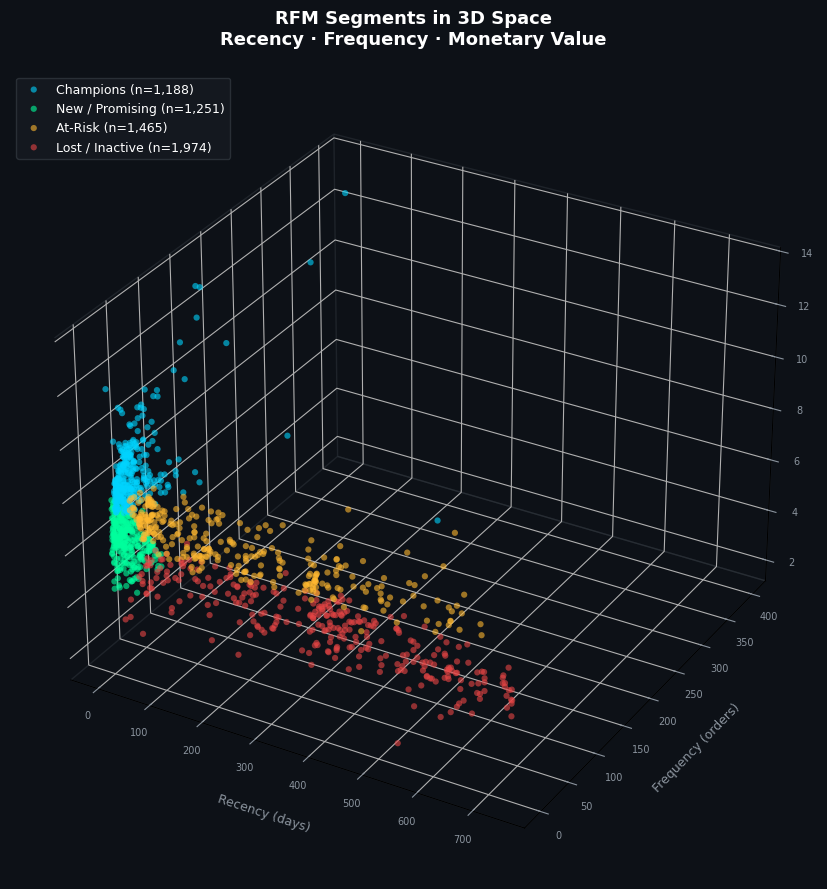

✅ Chart 2 saved


In [7]:
# ============================================================
# CELL 8: Chart 2 — RFM 3D Scatter Plot
# ============================================================

fig = plt.figure(figsize=(14, 9))
fig.patch.set_facecolor('#0D1117')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#0D1117')

for seg in seg_order:
    mask = rfm['Segment'] == seg
    subset = rfm[mask]
    # Sample for performance
    sample = subset.sample(min(300, len(subset)), random_state=42)
    ax.scatter(
        sample['Recency'],
        sample['Frequency'],
        np.log1p(sample['Monetary']),
        c=seg_colors[seg],
        label=f"{seg} (n={mask.sum():,})",
        alpha=0.6, s=20, edgecolors='none'
    )

ax.set_xlabel('Recency (days)', color='#8B949E', fontsize=9, labelpad=10)
ax.set_ylabel('Frequency (orders)', color='#8B949E', fontsize=9, labelpad=10)
ax.set_zlabel('Monetary log($)', color='#8B949E', fontsize=9, labelpad=10)
ax.tick_params(colors='#8B949E', labelsize=7)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#30363D')
ax.yaxis.pane.set_edgecolor('#30363D')
ax.zaxis.pane.set_edgecolor('#30363D')
ax.grid(True, color='#30363D', alpha=0.3)

legend = ax.legend(fontsize=9, facecolor='#161B22',
                   labelcolor='white', edgecolor='#30363D',
                   loc='upper left')
ax.set_title('RFM Segments in 3D Space\nRecency · Frequency · Monetary Value',
             fontsize=13, fontweight='bold', color='white', pad=20)

plt.tight_layout()
plt.savefig('chart_02_3d_scatter.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("✅ Chart 2 saved")

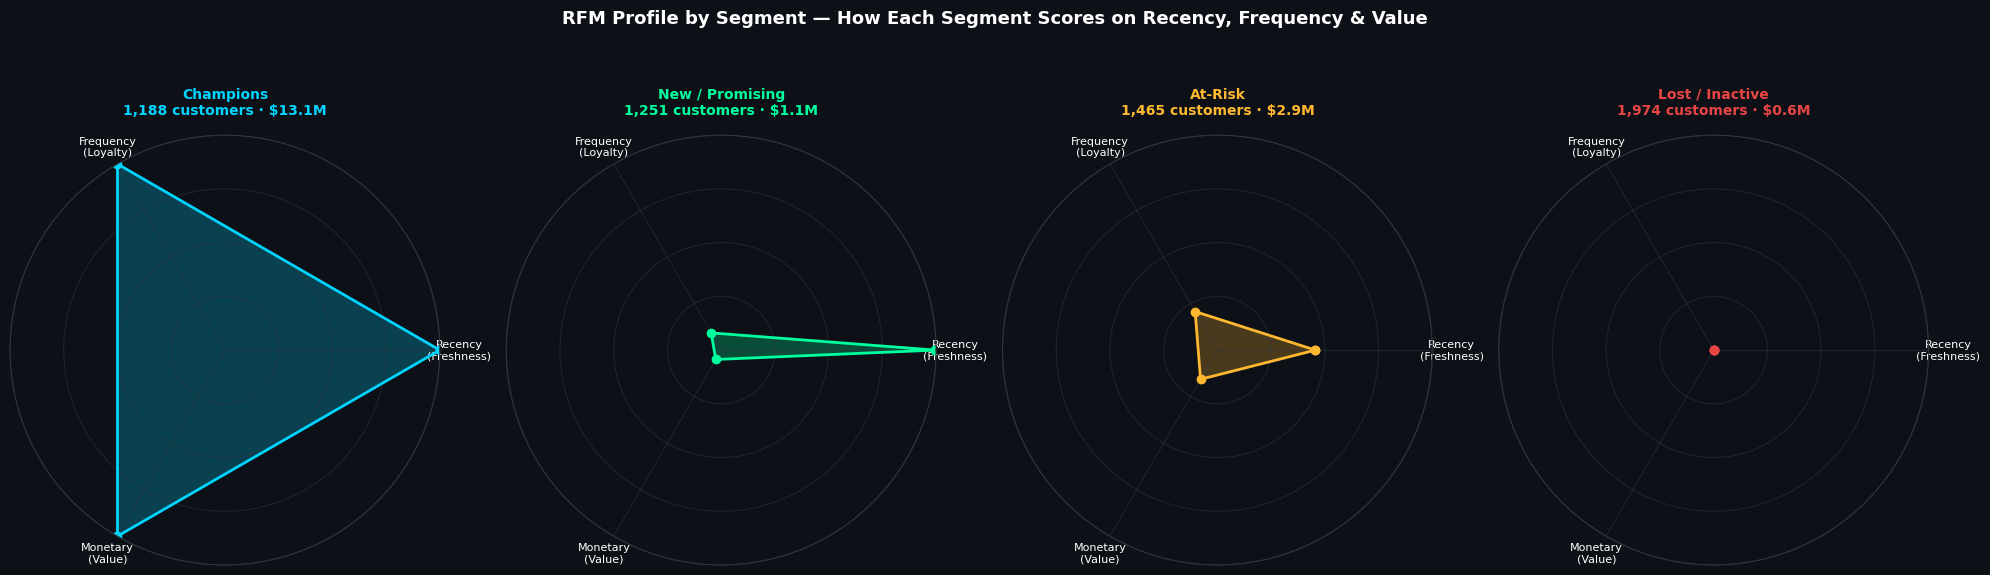

✅ Chart 3 saved


In [8]:
# ============================================================
# CELL 9: Chart 3 — Segment RFM Profile Radar Chart
# ============================================================

from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path

fig, axes = plt.subplots(1, 4, figsize=(20, 6), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0D1117')

# Normalize RFM for radar (0-1 scale)
# For Recency: invert so lower days = higher score
rfm_radar = segment_stats[['Avg_Recency','Avg_Frequency','Avg_Monetary']].copy()
rfm_radar['Recency_Score'] = 1 - (rfm_radar['Avg_Recency'] - rfm_radar['Avg_Recency'].min()) / \
                             (rfm_radar['Avg_Recency'].max() - rfm_radar['Avg_Recency'].min())
rfm_radar['Frequency_Score'] = (rfm_radar['Avg_Frequency'] - rfm_radar['Avg_Frequency'].min()) / \
                               (rfm_radar['Avg_Frequency'].max() - rfm_radar['Avg_Frequency'].min())
rfm_radar['Monetary_Score'] = (rfm_radar['Avg_Monetary'] - rfm_radar['Avg_Monetary'].min()) / \
                              (rfm_radar['Avg_Monetary'].max() - rfm_radar['Avg_Monetary'].min())

categories = ['Recency\n(Freshness)', 'Frequency\n(Loyalty)', 'Monetary\n(Value)']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for idx, seg in enumerate(seg_order):
    ax = axes[idx]
    ax.set_facecolor('#0D1117')
    color = seg_colors[seg]

    values = [
        rfm_radar.loc[seg, 'Recency_Score'],
        rfm_radar.loc[seg, 'Frequency_Score'],
        rfm_radar.loc[seg, 'Monetary_Score']
    ]
    values += values[:1]

    ax.plot(angles, values, 'o-', linewidth=2, color=color)
    ax.fill(angles, values, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=8, color='white')
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['', '', '', ''], size=6)
    ax.grid(color='#30363D', alpha=0.5)
    ax.spines['polar'].set_color('#30363D')

    cust_count = rfm['Segment'].value_counts()[seg]
    rev = segment_stats.loc[seg, 'Total_Revenue']
    ax.set_title(f'{seg}\n{cust_count:,} customers · ${rev/1e6:.1f}M',
                 fontsize=10, fontweight='bold', color=color, pad=15)

fig.suptitle('RFM Profile by Segment — How Each Segment Scores on Recency, Frequency & Value',
             fontsize=13, fontweight='bold', color='white', y=1.04)
plt.tight_layout()
plt.savefig('chart_03_radar_profiles.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("✅ Chart 3 saved")

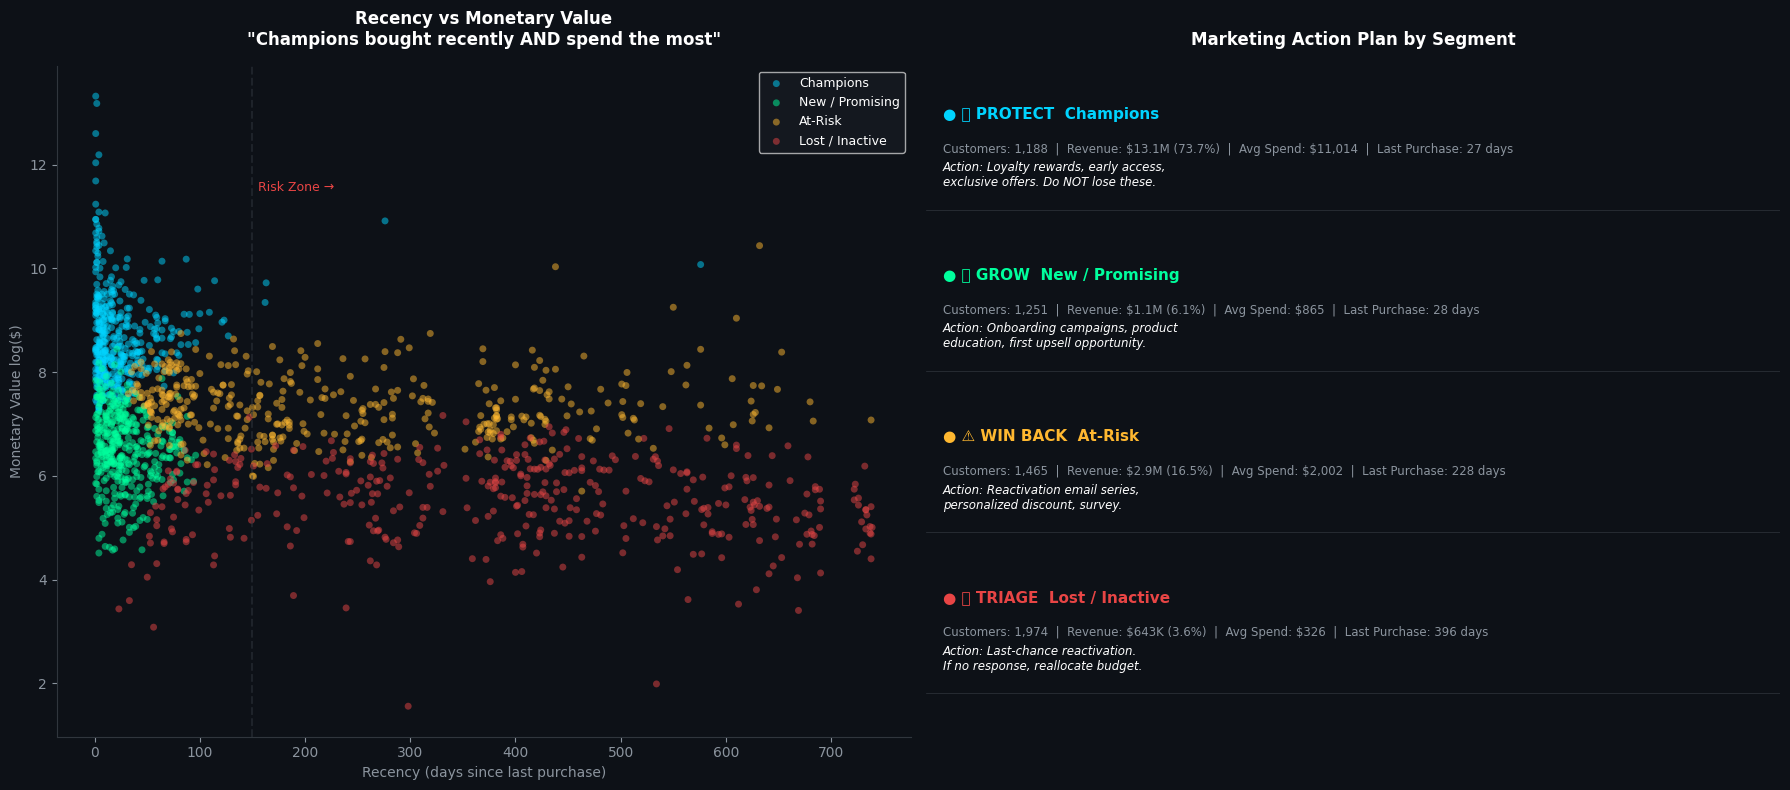

✅ Chart 4 saved


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming rfm, seg_order, seg_colors, segment_stats are defined from previous cells
# For demonstration, I'll mock them if they are not in the current context

# Mock data for demonstration if not available from previous cells
try:
    _ = rfm
except NameError:
    # Minimal mock for rfm dataframe
    rfm = pd.DataFrame({
        'Segment': ['Champions', 'New / Promising', 'At-Risk', 'Lost / Inactive', 'Champions', 'At-Risk'],
        'Recency': [20, 30, 200, 400, 25, 250],
        'Frequency': [15, 3, 5, 1, 18, 4],
        'Monetary': [10000, 800, 2500, 300, 12000, 2000]
    })
try:
    _ = seg_colors
except NameError:
    seg_colors = {
        'Champions':       '#00D4FF',
        'New / Promising': '#00FF9D',
        'At-Risk':         '#FFB830',
        'Lost / Inactive': '#E84545'
    }
try:
    _ = seg_order
except NameError:
    seg_order = ['Champions', 'New / Promising', 'At-Risk', 'Lost / Inactive']
try:
    _ = segment_stats
except NameError:
    segment_stats = pd.DataFrame({
        'Total_Revenue': [13.1e6, 1.1e6, 2.9e6, 0.643e6],
        'Customers': [1188, 1251, 1465, 1974],
        'Avg_Recency': [27.43, 28.44, 227.87, 395.86],
        'Avg_Frequency': [19.34, 3.04, 5.10, 1.38],
        'Avg_Monetary': [11014.37, 865.11, 2002.10, 325.75]
    }, index=seg_order)

# ============================================================
# CELL 10: Chart 4 — Business Action Matrix
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#0D1117')

# --- Recency vs Monetary scatter ---
ax1.set_facecolor('#0D1117')
for seg in seg_order:
    mask = rfm['Segment'] == seg
    subset = rfm[mask].sample(min(400, mask.sum()), random_state=42)
    ax1.scatter(
        subset['Recency'],
        np.log1p(subset['Monetary']),
        c=seg_colors[seg],
        label=seg,
        alpha=0.5, s=25, edgecolors='none'
    )

ax1.set_xlabel('Recency (days since last purchase)', color='#8B949E', fontsize=10)
ax1.set_ylabel('Monetary Value log($)', color='#8B949E', fontsize=10)
ax1.set_title('Recency vs Monetary Value\n"Champions bought recently AND spend the most"',
              fontsize=12, fontweight='bold', color='white', pad=15)
ax1.legend(fontsize=9, facecolor='#161B22', labelcolor='white')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_color('#30363D')
ax1.spines['left'].set_color('#30363D')
ax1.tick_params(colors='#8B949E')
ax1.axvline(x=150, color='#30363D', linestyle='--', alpha=0.5)
ax1.text(155, 11.5, 'Risk Zone →', color='#E84545', fontsize=9)

# --- Business action table ---
ax2.set_facecolor('#0D1117')
ax2.axis('off')

actions = {
    'Champions':       {
        'color': '#00D4FF',
        'customers': '1,188',
        'revenue': '\$13.1M (73.7%)',
        'avg_spend': '\$11,014',
        'days_since': '27 days',
        'priority': '🔒 PROTECT',
        'action': 'Loyalty rewards, early access,\nexclusive offers. Do NOT lose these.'
    },
    'New / Promising': {
        'color': '#00FF9D',
        'customers': '1,251',
        'revenue': '\$1.1M (6.1%)',
        'avg_spend': '\$865',
        'days_since': '28 days',
        'priority': '📈 GROW',
        'action': 'Onboarding campaigns, product\neducation, first upsell opportunity.'
    },
    'At-Risk': {
        'color': '#FFB830',
        'customers': '1,465',
        'revenue': '\$2.9M (16.5%)',
        'avg_spend': '\$2,002',
        'days_since': '228 days',
        'priority': '⚠️ WIN BACK',
        'action': 'Reactivation email series,\npersonalized discount, survey.'
    },
    'Lost / Inactive': {
        'color': '#E84545',
        'customers': '1,974',
        'revenue': '\$643K (3.6%)',
        'avg_spend': '\$326',
        'days_since': '396 days',
        'priority': '💀 TRIAGE',
        'action': 'Last-chance reactivation.\nIf no response, reallocate budget.'
    }
}

y_pos = 0.92
for seg, data in actions.items():
    color = data['color']
    # Segment header
    ax2.text(0.02, y_pos, f"● {data['priority']}  {seg}",
             fontsize=11, fontweight='bold', color=color,
             transform=ax2.transAxes)
    # Stats row
    ax2.text(0.02, y_pos - 0.05,
             f"Customers: {data['customers']}  |  Revenue: {data['revenue']}  |  "
             f"Avg Spend: {data['avg_spend']}  |  Last Purchase: {data['days_since']}",
             fontsize=8.5, color='#8B949E', transform=ax2.transAxes)
    # Action
    ax2.text(0.02, y_pos - 0.10, f"Action: {data['action']}",
             fontsize=8.5, color='white', transform=ax2.transAxes,
             style='italic')
    # Divider
    ax2.axhline(y=y_pos - 0.135, xmin=0.0, xmax=1.0,
                color='#30363D', linewidth=0.5)
    y_pos -= 0.24

ax2.set_title('Marketing Action Plan by Segment',
              fontsize=12, fontweight='bold', color='white', pad=15)

plt.tight_layout()
plt.savefig('chart_04_action_matrix.png', dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("✅ Chart 4 saved")

In [10]:
# ============================================================
# DOWNLOAD ALL CHARTS + NOTEBOOK
# ============================================================

from google.colab import files

files.download('chart_01_segment_overview.png')
files.download('chart_02_3d_scatter.png')
files.download('chart_03_radar_profiles.png')
files.download('chart_04_action_matrix.png')

print("All charts downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All charts downloaded
